In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("C:/Users/ary53/Downloads/Titanic-Dataset.csv")    

print("Shape of Dataset:", df.shape)

print("\nFirst 5 Rows")
print(df.head())

print("\nData Types")
print(df.dtypes)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

Shape of Dataset: (891, 12)

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0     

In [19]:
print(df.describe())

print(df.describe(include='all'))

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
        PassengerId    Survived      Pclass                     Name   Sex  \
cou

In [20]:
print(df.describe())

print(df.describe(include='all'))

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
        PassengerId    Survived      Pclass                     Name   Sex  \
cou

In [21]:
df["Age"].fillna(df["Age"].median(), inplace=True)

In [27]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [28]:
df["Cabin"].fillna("Unknown", inplace=True)

In [29]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


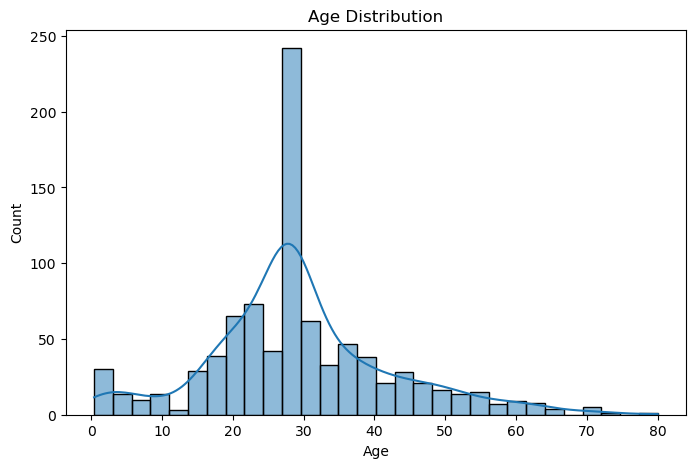

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

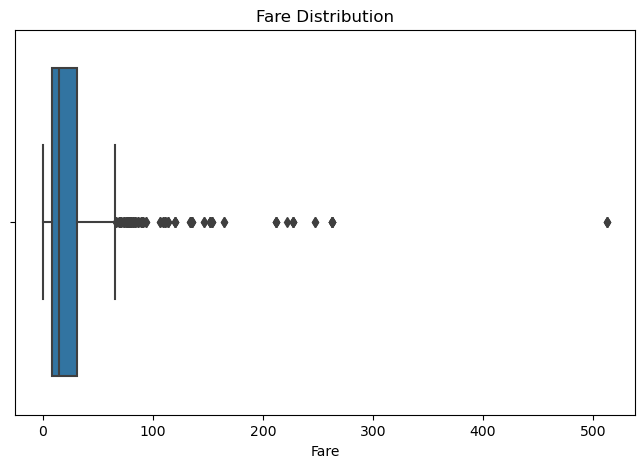

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Distribution")

plt.show()

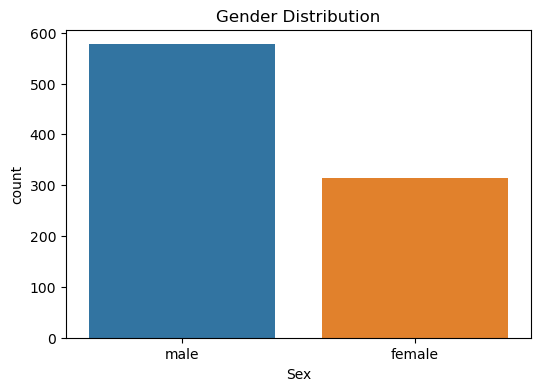

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.show()

AttributeError: 'numpy.int64' object has no attribute 'startswith'

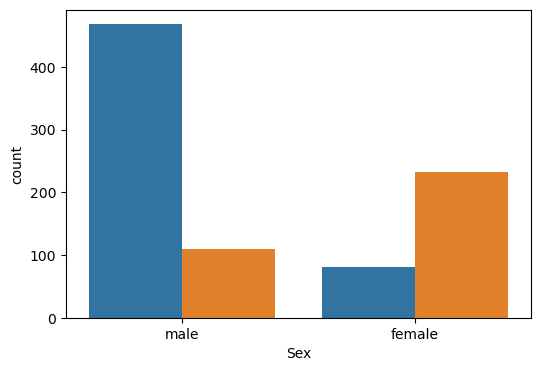

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.show()

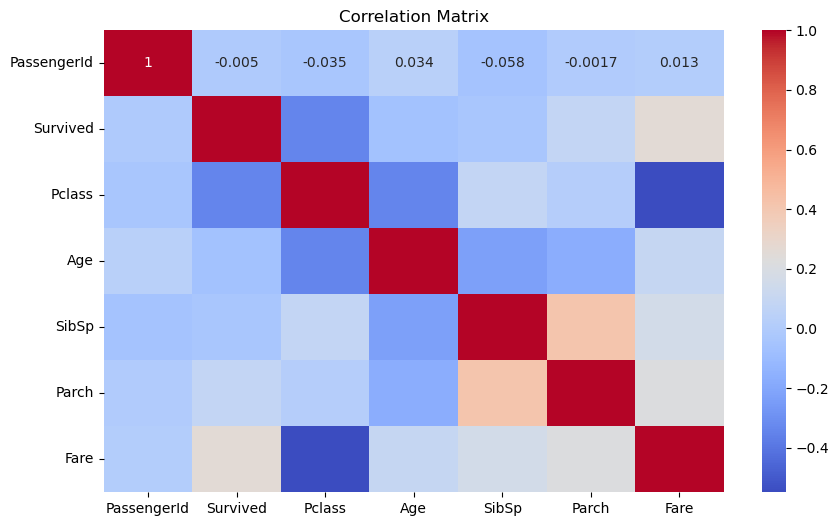

In [34]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [35]:
cross = pd.crosstab(df["Pclass"],
                    df["Survived"],
                    normalize="index")*100

print(cross)

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


In [36]:
gender = pd.crosstab(df["Sex"],
                     df["Survived"],
                     normalize="index")*100

print(gender)

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


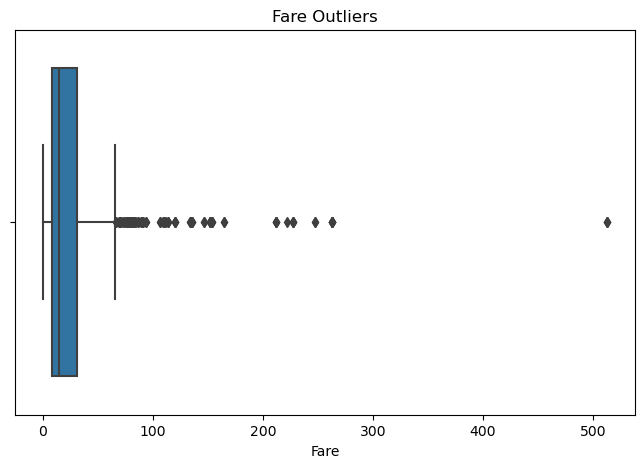

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Outliers")

plt.show()

In [38]:
from scipy import stats

z_scores = np.abs(stats.zscore(df["Fare"]))

outliers = df[z_scores > 3]

print("Number of Outliers:", len(outliers))

print(outliers.head())

Number of Outliers: 20
     PassengerId  Survived  Pclass  \
27            28         0       1   
88            89         1       1   
118          119         0       1   
258          259         1       1   
299          300         1       1   

                                                Name     Sex   Age  SibSp  \
27                    Fortune, Mr. Charles Alexander    male  19.0      3   
88                        Fortune, Miss. Mabel Helen  female  23.0      3   
118                         Baxter, Mr. Quigg Edmond    male  24.0      0   
258                                 Ward, Miss. Anna  female  35.0      0   
299  Baxter, Mrs. James (Helene DeLaudeniere Chaput)  female  50.0      0   

     Parch    Ticket      Fare        Cabin Embarked  
27       2     19950  263.0000  C23 C25 C27        S  
88       2     19950  263.0000  C23 C25 C27        S  
118      1  PC 17558  247.5208      B58 B60        C  
258      0  PC 17755  512.3292      Unknown        C  
299      1

C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


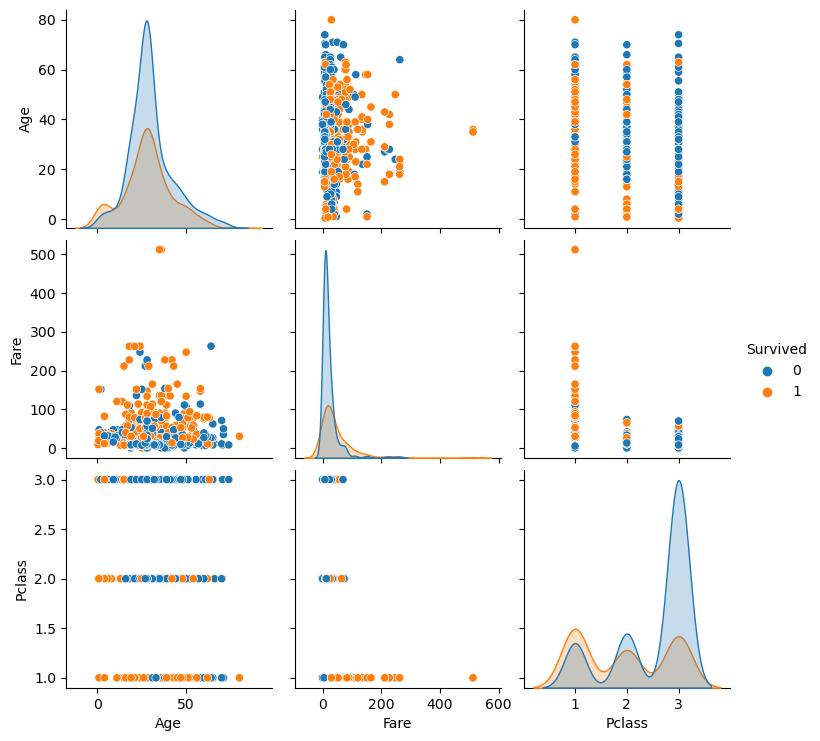

In [39]:
sns.pairplot(df[["Age",
                 "Fare",
                 "Pclass",
                 "Survived"]],
             hue="Survived")

plt.show()

C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

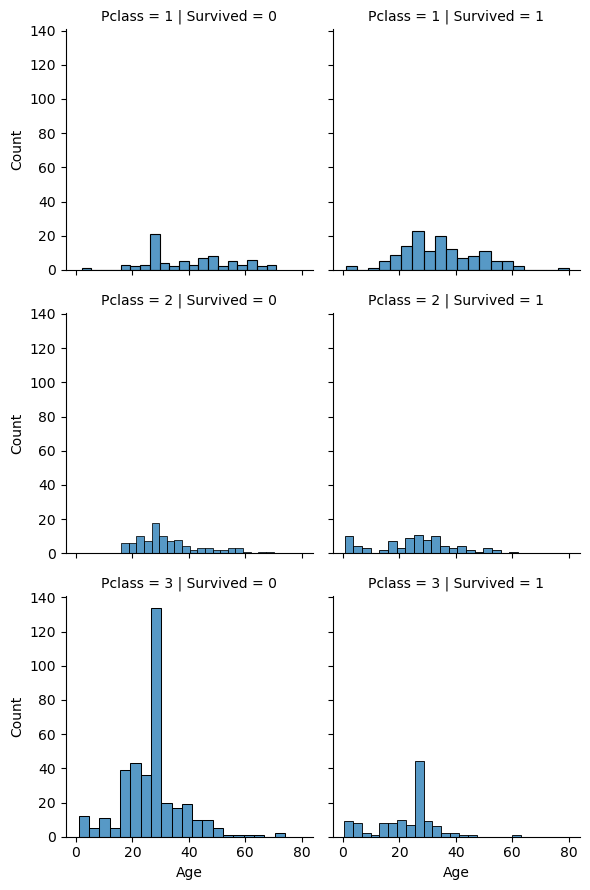

In [40]:
g = sns.FacetGrid(df,
                  col="Survived",
                  row="Pclass",
                  height=3)

g.map(sns.histplot,
      "Age",
      bins=20)

plt.show()